<a href="https://colab.research.google.com/github/nikhil1234108/data-science/blob/main/MLMODELS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN REGRESSOR



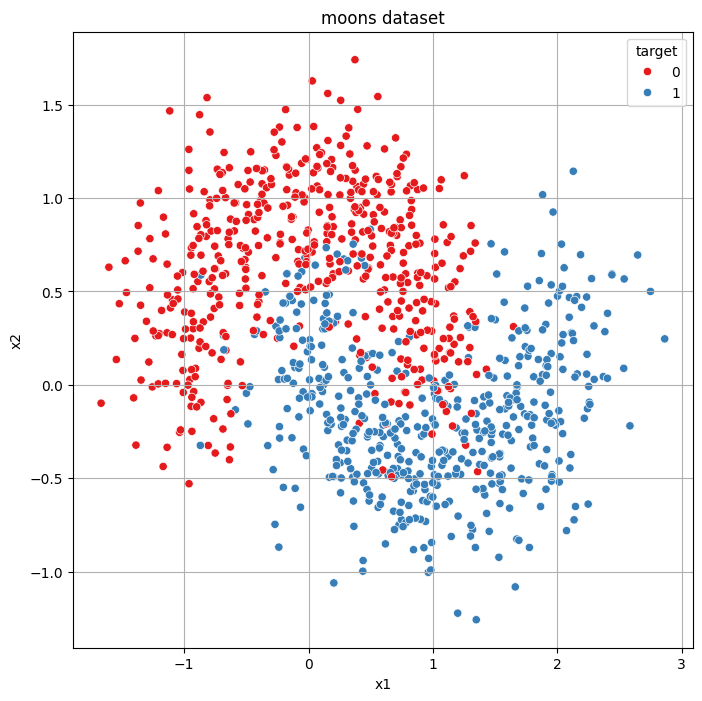

In [ ]:
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns
  from sklearn.datasets import make_moons

  x,y = make_moons(n_samples=1000,noise=0.3,random_state=42)

  df = pd.DataFrame(x,columns=['x1','x2'])
  df['target'] = y

  plt.figure(figsize=(8,8))
  sns.scatterplot(data=df,x='x1',y='x2',hue='target',palette="Set1")
  plt.xlabel('x1')
  plt.ylabel('x2')
  plt.title('moons dataset')
  plt.grid(True)
  plt.legend(title='target')
  plt.show()

In [ ]:
df.head()

,x1,x2,target
0,-0.171863,0.596249,1
1,1.253283,-0.265414,1
2,0.723224,0.231943,1
3,-0.065198,-0.655194,1
4,-0.799493,0.552935,0


In [ ]:
df.describe()

,x1,x2,target
count,1000.000000,1000.000000,1000.00000
mean,0.495520,0.241961,0.50000
std,0.917175,0.571628,0.50025
min,-1.669007,-1.257494,0.00000
25%,-0.134887,-0.209607,0.00000
50%,0.502420,0.234512,0.50000
75%,1.127110,0.695783,1.00000
max,2.863928,1.740967,1.00000


In [ ]:
df.isnull().sum()

,0
x1,0
x2,0
target,0


<Axes: xlabel='target', ylabel='x1'>

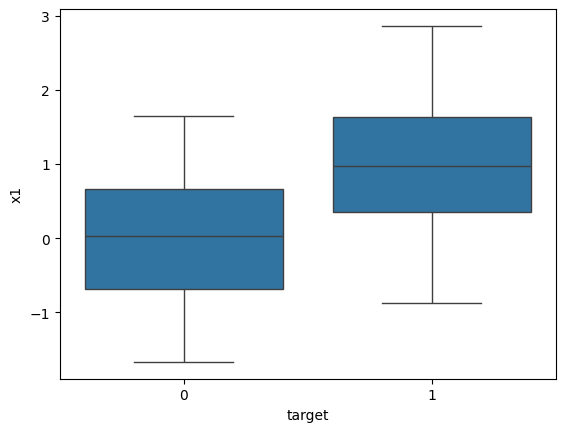

In [ ]:
sns.boxplot(data=df,x='target',y='x1')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_scaler = scaler.fit_transform(x)

x_train,x_test,y_train,y_test = train_test_split(x_scaler,y,test_size=0.3,random_state=42,stratify=y)


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsRegressor()

In [ ]:
y_pred=knn.predict(x_test)

In [ ]:
from sklearn.metrics import mean_squared_error

print(f"mean_squared_error:{mean_squared_error(y_test,y_pred)}")

mean_squared_error:0.0556


In [ ]:
from sklearn.metrics import r2_score

print(f"r2_score:{r2_score(y_test,y_pred)}")

r2_score:0.7776000000000001


In [ ]:
from sklearn.metrics import root_mean_squared_error

print(f"root_mean_squared_error:{root_mean_squared_error(y_test,y_pred)}")

root_mean_squared_error:0.23579652245103191


In [ ]:
from sklearn.model_selection import cross_val_score
k_range = range(1,31)
cv_scores=[]

for k in (k_range):
  knn1 = KNeighborsRegressor(n_neighbors=k)
  scores = cross_val_score(knn1,x_train,y_train,cv=5,scoring='r2')
  cv_scores.append(scores.mean())

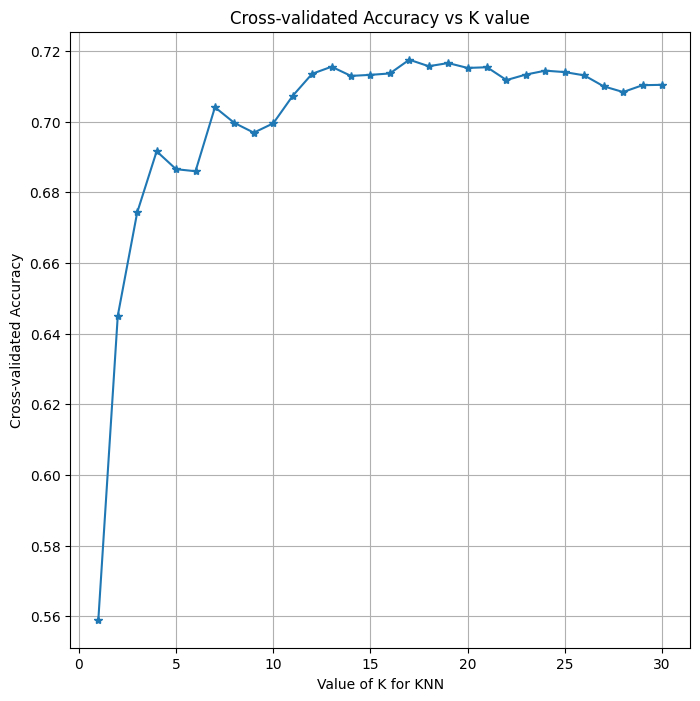

In [ ]:
plt.figure(figsize=(8,8))
plt.plot(k_range,cv_scores,marker='*')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-validated Accuracy')
plt.title('Cross-validated Accuracy vs K value')
plt.grid(True)
plt.show()

In [ ]:
best_k=k_range[np.argmax(cv_scores)]
print(f"Best k value:{best_k}")

Best k value:17


In [ ]:
best_knn = KNeighborsRegressor(n_neighbors=best_k)
best_knn.fit(x_train,y_train)

y_pred1=knn.predict(x_test)

In [ ]:
print(f"mean_squared_error:{mean_squared_error(y_test,y_pred1)}")

mean_squared_error:0.0556


In [ ]:
print(f"r2_score:{r2_score(y_test,y_pred1)}")

r2_score:0.7776000000000001


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(x_train,y_train)

KNeighborsClassifier()

In [ ]:
y_pred2 = knn_clf.predict(x_test)
print(f"accuracy_score:{accuracy_score(y_test,y_pred2)}")
print(f"confusion_matrix:\n{confusion_matrix(y_test,y_pred2)}")
print(f"classification_report:\n{classification_report(y_test,y_pred2)}")

accuracy_score:0.9333333333333333
confusion_matrix:
[[144   6]
 [ 14 136]]
classification_report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       150
           1       0.96      0.91      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



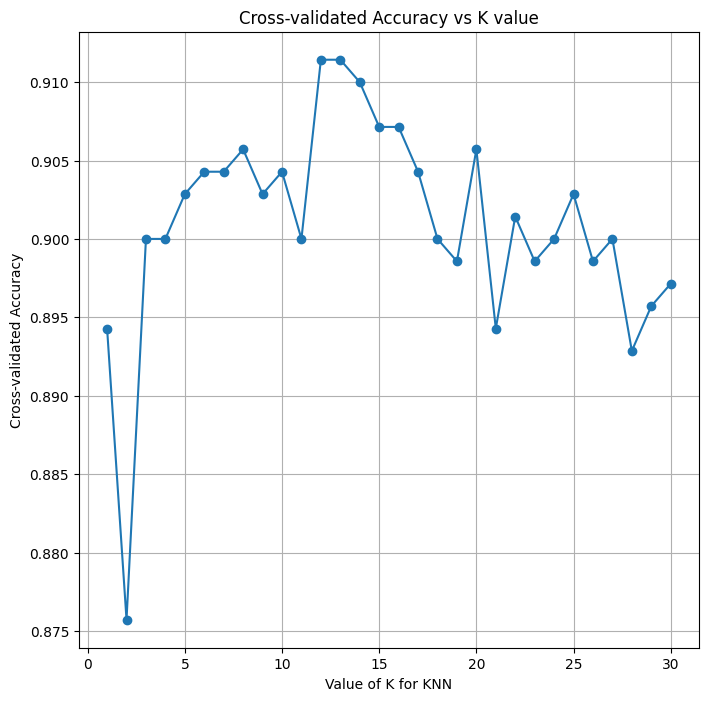

In [ ]:
from sklearn.model_selection import cross_val_score
k_range = range(1,31)
val_scores1 = []

for k in (k_range):
  knn_clf1 = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(knn_clf1,x_train,y_train,cv=5,scoring='accuracy')
  val_scores1.append(scores.mean())

plt.figure(figsize=(8,8))
plt.plot(k_range,val_scores1,marker='o')
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-validated Accuracy')
plt.title('Cross-validated Accuracy vs K value')
plt.grid(True)
plt.show()

In [ ]:
best_k=k_range[np.argmax(val_scores1)]
print(f"Best k value:{best_k}")

Best k value:12


In [ ]:
knn2 = KNeighborsClassifier(n_neighbors=best_k)
knn2.fit(x_train,y_train)

knn2.fit(x_train,y_train)
y_pred3 = knn2.predict(x_test)

print(f"accuracy_score:{accuracy_score(y_test,y_pred3)}")
print(f"confusion_matrix:\n{confusion_matrix(y_test,y_pred3)}")
print(f"classification_report:\n{classification_report(y_test,y_pred3)}")

accuracy_score:0.93
confusion_matrix:
[[144   6]
 [ 15 135]]
classification_report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       150
           1       0.96      0.90      0.93       150

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



<Figure size 800x800 with 0 Axes>

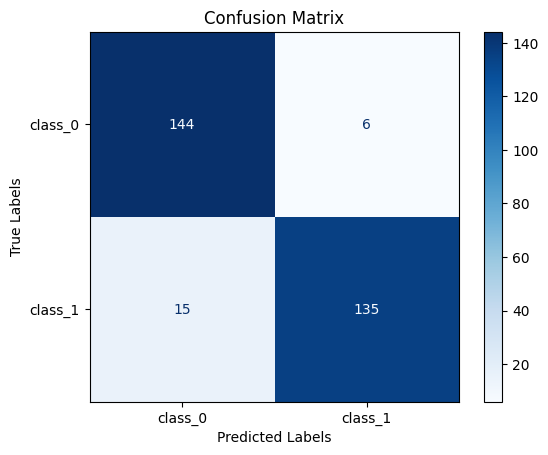

In [ ]:
cm = confusion_matrix(y_test,y_pred3)
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8,8))
ConfusionMatrixDisplay(cm,display_labels=["class_0","class_1"]).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

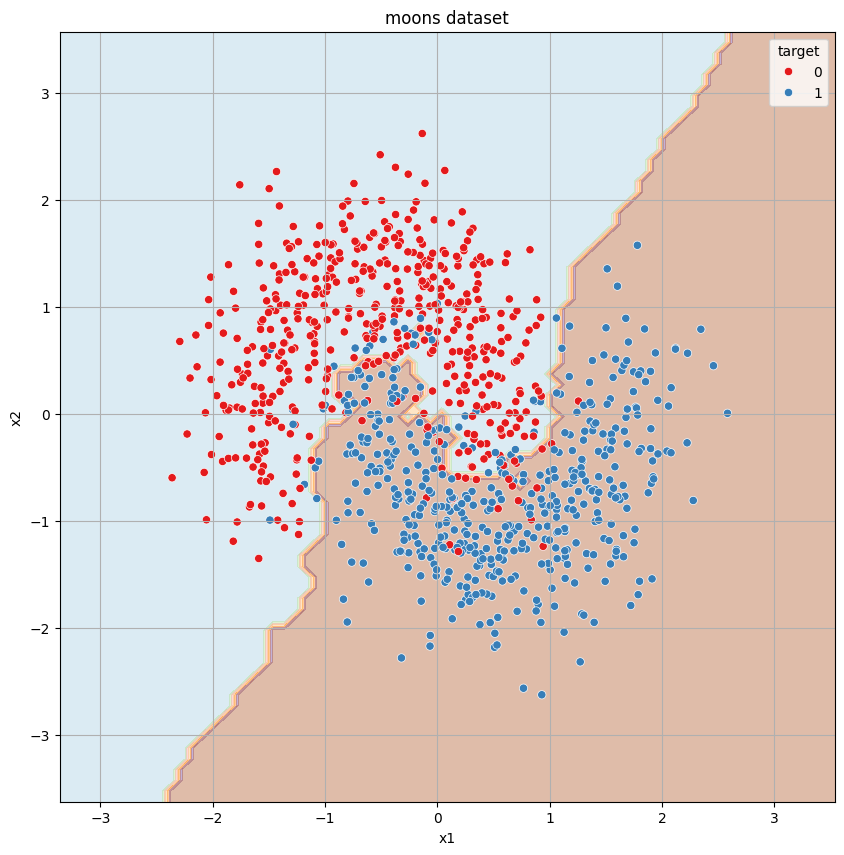

In [ ]:
x_min,x_max = x_scaler[:,0].min()-1,x_scaler[:,0].max()+1
y_min,y_max = x_scaler[:,1].min()-1,x_scaler[:,1].max()+1

xx,yy = np.meshgrid(np.arange(x_min,x_max,0.1),np.arange(y_min,y_max,0.1))

z = knn2.predict(np.c_[xx.ravel(),yy.ravel()])
z = z.reshape(xx.shape)

plt.figure(figsize=(10,10))
plt.contourf(xx,yy,z,cmap=plt.cm.Paired,alpha=0.4)
sns.scatterplot(x=x_scaler[:,0],y=x_scaler[:,1],hue=y,palette='Set1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('moons dataset')
plt.grid(True)
plt.legend(title='target')
plt.show()

In [ ]:
z.shape

(73, 70)

# GRIDSEARCH CV

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,ConfusionMatrixDisplay

In [ ]:
data = load_breast_cancer()
df_data = pd.DataFrame(data=data.data,columns=data.feature_names)
df_data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df_data.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


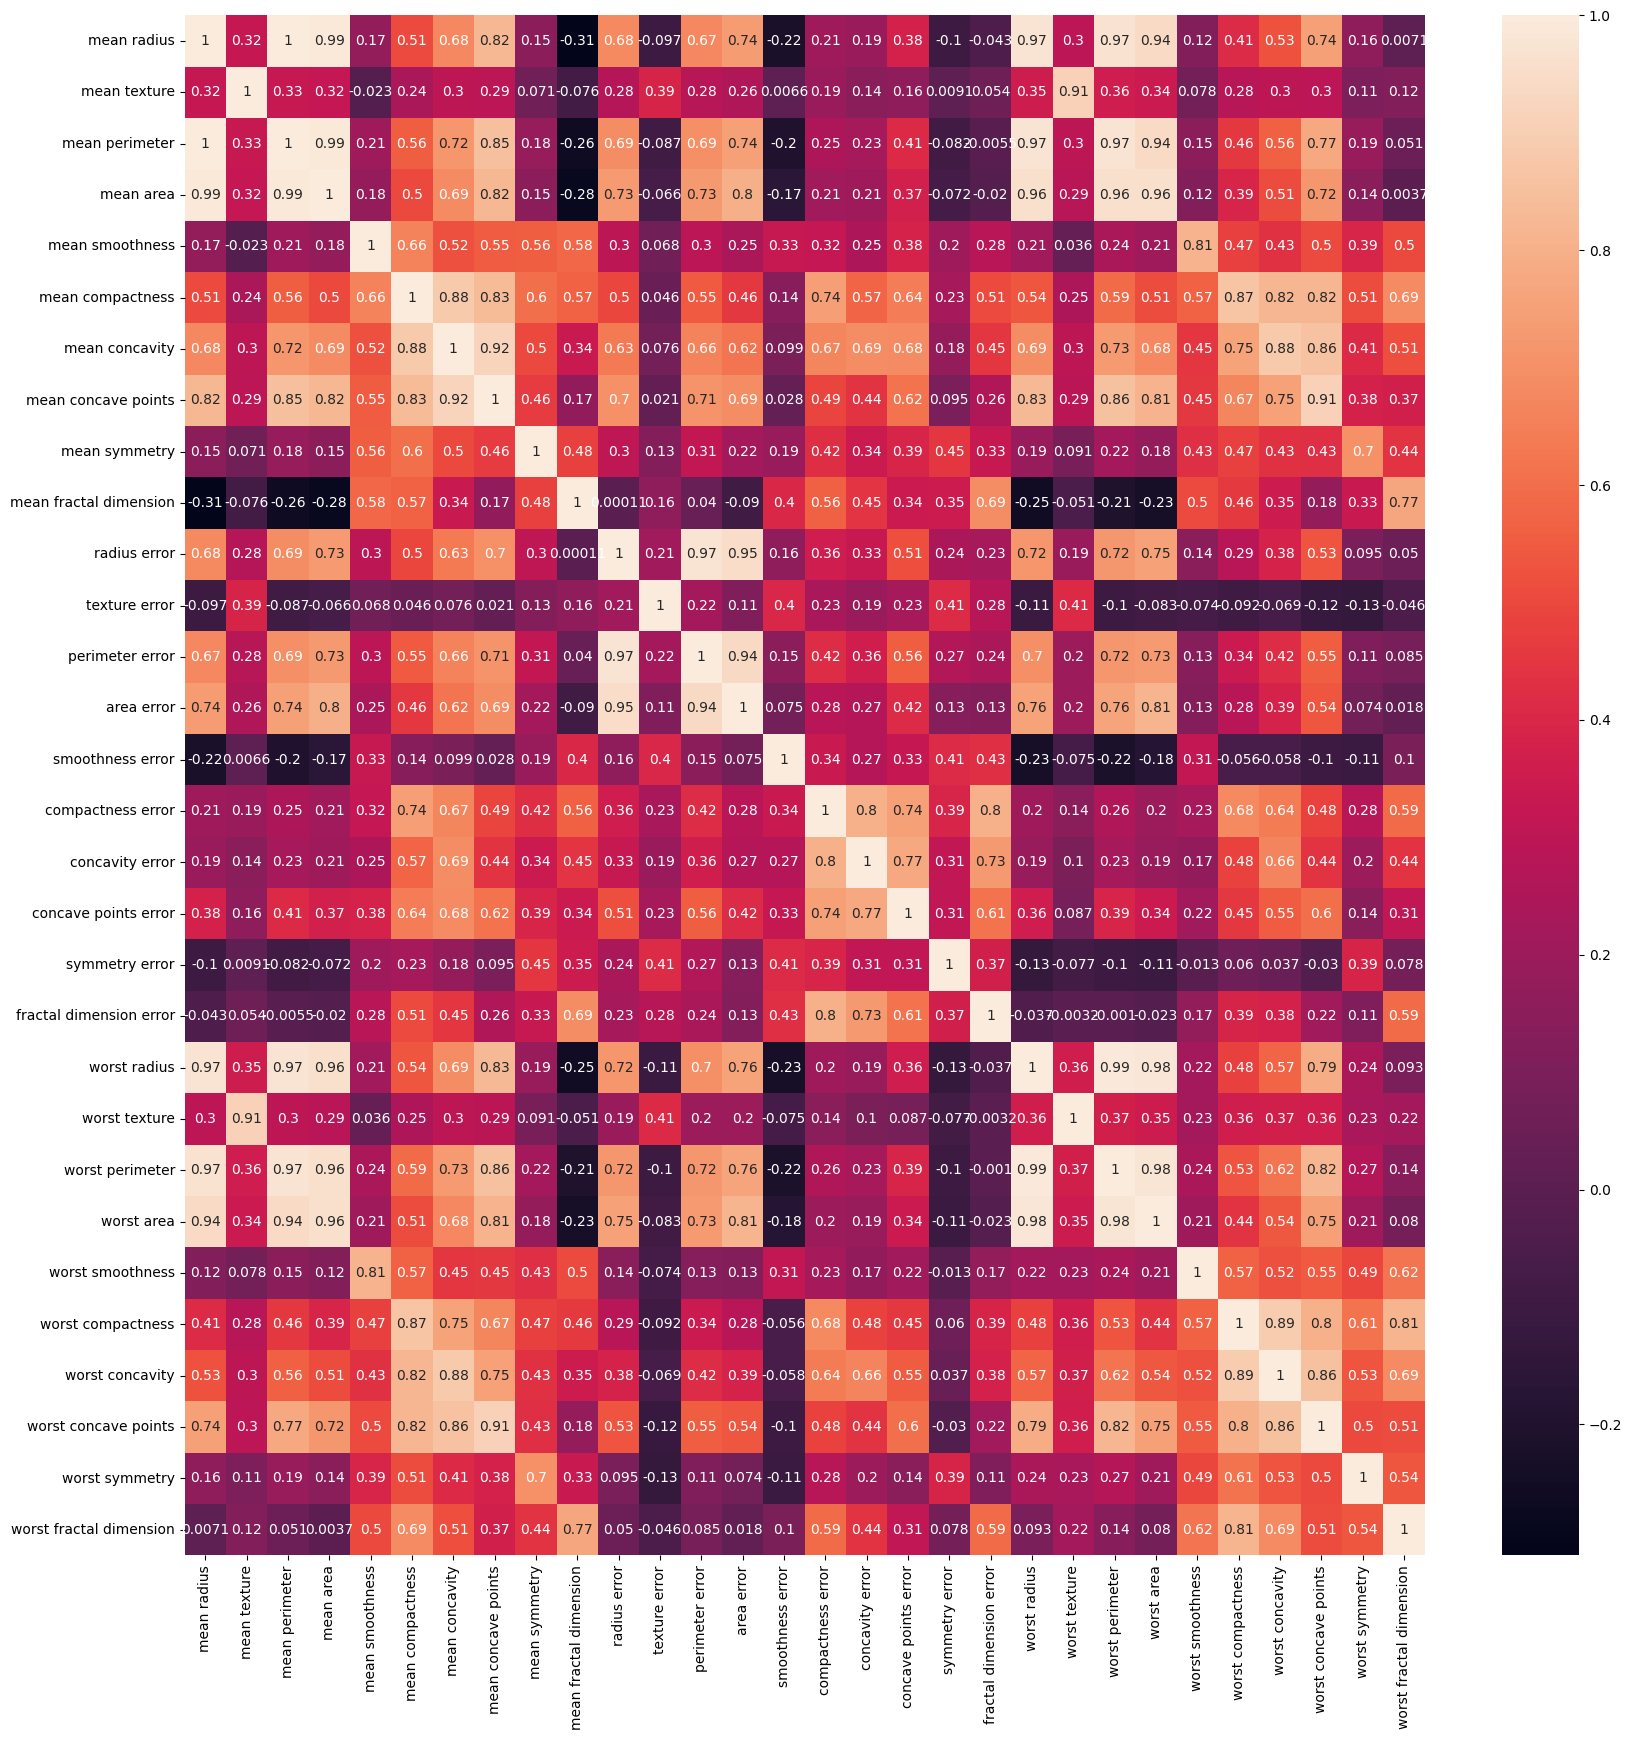

In [ ]:
df_corr = df_data.corr()
plt.figure(figsize=(20,20))
sns.heatmap(df_corr,annot=True)
plt.show()

In [ ]:
x = df_data
y = data.target

In [ ]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [ ]:
print(f"x_train shape:{x_train.shape}")
print(f"x_test shape:{x_test.shape}")
print(f"y_train shape:{y_train.shape}")
print(f"y_test shape:{y_test.shape}")

x_train shape:(398, 30)
x_test shape:(171, 30)
y_train shape:(398,)
y_test shape:(171,)


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(x_train,y_train)

feature_importances = model.feature_importances_
feature_importance_series = pd.Series(feature_importances,index=x_train.columns)
feature_importance_series.sort_values(ascending=False,inplace=True)
print(feature_importance_series)

worst concave points       0.112213
worst radius               0.110015
worst perimeter            0.098239
mean concave points        0.069818
mean area                  0.065862
worst area                 0.059490
mean radius                0.048456
worst concavity            0.046756
mean perimeter             0.045622
area error                 0.042375
mean concavity             0.042117
worst smoothness           0.027342
worst compactness          0.026219
mean compactness           0.024500
radius error               0.021062
mean texture               0.020777
worst texture              0.020647
perimeter error            0.016893
worst symmetry             0.014538
mean smoothness            0.012844
concave points error       0.010716
worst fractal dimension    0.009659
compactness error          0.008724
concavity error            0.007438
fractal dimension error    0.007131
mean fractal dimension     0.006873
mean symmetry              0.006834
smoothness error           0

In [ ]:
clf = RandomForestClassifier(random_state=42,class_weight='balanced')

rfecv = RFECV(estimator=clf,step=2,cv=StratifiedKFold(10),scoring='roc_auc')

pipeline = Pipeline([('feature_selection',rfecv),('classification',clf)])

In [ ]:
param_grid = {
    'classification__n_estimators':[100,200,300],
    'classification__max_depth':[4,5,6,7,8],
    'classification__max_features':['sqrt','log2'],
    'classification__criterion':['gini','entropy']
}

In [ ]:
GC = GridSearchCV(estimator=pipeline,param_grid=param_grid,cv=StratifiedKFold(10),scoring='roc_auc',n_jobs=1, verbose=2)
GC.fit(x_train,y_train)

Fitting 10 folds for each of 60 candidates, totalling 600 fits
[CV] END classification__criterion=gini, classification__max_depth=4, classification__max_features=sqrt, classification__n_estimators=100; total time=  35.0s
[CV] END classification__criterion=gini, classification__max_depth=4, classification__max_features=sqrt, classification__n_estimators=100; total time=  35.2s
[CV] END classification__criterion=gini, classification__max_depth=4, classification__max_features=sqrt, classification__n_estimators=100; total time=  35.1s
[CV] END classification__criterion=gini, classification__max_depth=4, classification__max_features=sqrt, classification__n_estimators=100; total time=  33.0s
[CV] END classification__criterion=gini, classification__max_depth=4, classification__max_features=sqrt, classification__n_estimators=100; total time=  33.9s
[CV] END classification__criterion=gini, classification__max_depth=4, classification__max_features=sqrt, classification__n_estimators=100; total ti

# RFECV ALLMIX


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing # Changed from fetch_boston
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

In [2]:
california = fetch_california_housing()
df = pd.DataFrame(data=california.data,columns=california.feature_names)
df['target'] = california.target
df.head()
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [3]:
df.count().isnull()

,0
MedInc,False
HouseAge,False
AveRooms,False
AveBedrms,False
Population,False
AveOccup,False
Latitude,False
Longitude,False
target,False


In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


<function matplotlib.pyplot.show(close=None, block=None)>

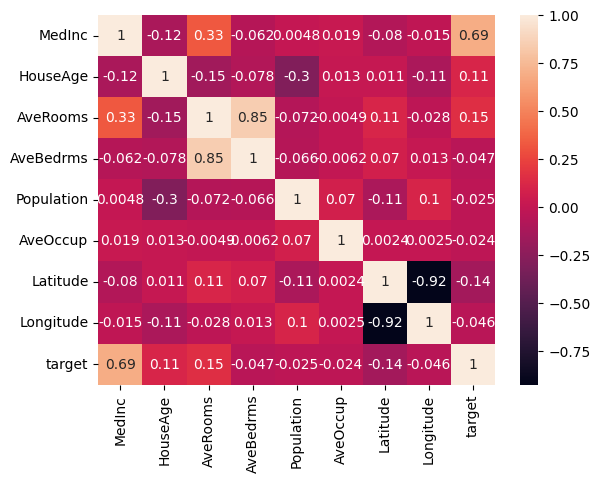

In [5]:
dfcorr = df.corr()
dfcorr
sns.heatmap(dfcorr,annot=True)
plt.show

In [6]:
x_train,x_test,y_train,y_test=train_test_split(df.drop('target',axis=1),df['target'],test_size=0.3,random_state=42)

In [7]:
from sklearn.ensemble import ExtraTreesRegressor

model = ExtraTreesRegressor(n_estimators=100,max_depth=7)
model.fit(x_train,y_train)

feature_importances = model.feature_importances_
feature_importance_series = pd.Series(feature_importances,index=x_train.columns)
feature_importance_series.sort_values(ascending=False,inplace=True)
print(feature_importance_series)

MedInc        0.815227
Latitude      0.060575
HouseAge      0.050670
Longitude     0.038932
AveOccup      0.018293
AveRooms      0.012226
AveBedrms     0.002466
Population    0.001610
dtype: float64


In [8]:
from sklearn.model_selection import KFold

cv_strategy = KFold(n_splits=5,shuffle=True,random_state=42)

In [9]:
rfecv_base_estimator = LinearRegression()

In [10]:
scoring_metrics = ['neg_mean_absolute_error','neg_mean_squared_error','r2']

In [11]:
model_configurations = {
    'RandomForestRegressor':{
        'clf':RandomForestRegressor(random_state=42),
        'param_grid':{
            'regression__n_estimators':[100,200],
            'regression__max_depth':[4,5,6],
            'regression__max_features':['sqrt','log2']
        }
    },
    'KNeighborsRegressor':{
        'clf':KNeighborsRegressor(),
        'param_grid':{
            'regression__n_neighbors':[3,5,7],
            'regression__weights':['uniform','distance']
        }
    },
    'GradientBoostingRegressor':{
        'clf':GradientBoostingRegressor(random_state=42),
        'param_grid':{
            'regression__n_estimators':[100,200],
            'regression__max_depth':[4,5,6],
            'regression__learning_rate':[0.1,0.05]
        }
    },
    'SVR':{
        'clf':SVR(),
        'param_grid':{
            'regression__C':[1.0,2.0,3.0],
            'regression__kernel':['linear','rbf']
        }
    }
}

In [12]:
camparision_results = []

for name,config in model_configurations.items():
  print(f"Training model:{name}")
  clf = config['clf']
  param_grid = config['param_grid']

  rfecv = RFECV(estimator=rfecv_base_estimator,step=1,cv=cv_strategy,scoring='r2',n_jobs=1)

  pipeline = Pipeline([('feature_selection',rfecv),('regression',clf)])
  grid_search = GridSearchCV(
      estimator=pipeline,
      param_grid=param_grid,
      cv=cv_strategy,
      verbose=2,
      n_jobs=1,
      scoring=scoring_metrics,
      refit='r2'
  )
  grid_search.fit(x_train,y_train)

  best_model = grid_search.best_estimator_
  y_pred = best_model.predict(x_test)

  mae = mean_absolute_error(y_test,y_pred)
  mse = mean_squared_error(y_test,y_pred)
  r2 = r2_score(y_test,y_pred)
  rmse = np.sqrt(mse)

  best_rfecv = best_model['feature_selection']
  best_clf = best_model['regression']

  num_features = best_rfecv.n_features_
  selected_features = best_rfecv.get_feature_names_out(input_features=x_train.columns)

  best_params = grid_search.best_params_

  print(f"Best parameters:{best_params}")
  print(f"Number of selected features:{num_features}")
  print(f"Selected features:{selected_features}")

  best_cv_rmse = np.sqrt(-grid_search.best_score_)

  print(f"Best CV RMSE:{best_cv_rmse}")

  camparision_results.append({
      'model_name':name,
      'best_params':best_params,
      'num_features':num_features,
      'selected_features':selected_features,
      'MAE': mae,
      'MSE': mse,
      'R2': r2,
      'RMSE': rmse,
      'Best CV R2': grid_search.best_score_
      })

Training model:RandomForestRegressor
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END regression__max_depth=4, regression__max_features=sqrt, regression__n_estimators=100; total time=   2.2s
[CV] END regression__max_depth=4, regression__max_features=sqrt, regression__n_estimators=100; total time=   2.0s
[CV] END regression__max_depth=4, regression__max_features=sqrt, regression__n_estimators=100; total time=   1.9s
[CV] END regression__max_depth=4, regression__max_features=sqrt, regression__n_estimators=100; total time=   2.1s
[CV] END regression__max_depth=4, regression__max_features=sqrt, regression__n_estimators=100; total time=   1.7s
[CV] END regression__max_depth=4, regression__max_features=sqrt, regression__n_estimators=200; total time=   2.1s
[CV] END regression__max_depth=4, regression__max_features=sqrt, regression__n_estimators=200; total time=   2.2s
[CV] END regression__max_depth=4, regression__max_features=sqrt, regression__n_estimators=200; total tim

/tmp/ipython-input-520189467.py:42: RuntimeWarning: invalid value encountered in sqrt
  best_cv_rmse = np.sqrt(-grid_search.best_score_)


[CV] END regression__n_neighbors=3, regression__weights=uniform; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=uniform; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=uniform; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=uniform; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=uniform; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=distance; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=distance; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=distance; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=distance; total time=   0.2s
[CV] END regression__n_neighbors=3, regression__weights=distance; total time=   0.2s
[CV] END regression__n_neighbors=5, regression__weights=uniform; total time=   0.3s
[CV] END regression__n_neighbors=5, regression__weights=uniform; total 

/tmp/ipython-input-520189467.py:42: RuntimeWarning: invalid value encountered in sqrt
  best_cv_rmse = np.sqrt(-grid_search.best_score_)


[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   2.3s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   4.1s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   4.6s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   3.1s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   4.1s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=200; total time=   5.1s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=200; total time=   8.0s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=200; total time=   8.5s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimator

/tmp/ipython-input-520189467.py:42: RuntimeWarning: invalid value encountered in sqrt
  best_cv_rmse = np.sqrt(-grid_search.best_score_)


[CV] END .......regression__C=1.0, regression__kernel=linear; total time=  12.4s
[CV] END .......regression__C=1.0, regression__kernel=linear; total time= 1.6min
[CV] END .......regression__C=1.0, regression__kernel=linear; total time= 1.6min
[CV] END .......regression__C=1.0, regression__kernel=linear; total time=  15.0s
[CV] END .......regression__C=1.0, regression__kernel=linear; total time= 1.6min
[CV] END ..........regression__C=1.0, regression__kernel=rbf; total time=   6.7s
[CV] END ..........regression__C=1.0, regression__kernel=rbf; total time=   5.9s
[CV] END ..........regression__C=1.0, regression__kernel=rbf; total time=   6.7s
[CV] END ..........regression__C=1.0, regression__kernel=rbf; total time=   5.7s
[CV] END ..........regression__C=1.0, regression__kernel=rbf; total time=   6.8s
[CV] END .......regression__C=2.0, regression__kernel=linear; total time=  18.7s
[CV] END .......regression__C=2.0, regression__kernel=linear; total time= 3.9min
[CV] END .......regression__

/tmp/ipython-input-520189467.py:42: RuntimeWarning: invalid value encountered in sqrt
  best_cv_rmse = np.sqrt(-grid_search.best_score_)


In [16]:
df_results = pd.DataFrame(camparision_results).sort_values(by='RMSE',ascending=True)
df_results.reset_index(drop=True,inplace=True)
print(df_results[['MAE','MSE','RMSE','R2']])

        MAE       MSE      RMSE        R2
0  0.304987  0.213269  0.461810  0.837514
1  0.420133  0.375180  0.612520  0.714157
2  0.471581  0.411900  0.641795  0.686181
3  0.509492  0.549874  0.741535  0.581061


In [17]:
print(df_results)

                  model_name  \
0  GradientBoostingRegressor   
1        KNeighborsRegressor   
2      RandomForestRegressor   
3                        SVR   

                                         best_params  num_features  \
0  {'regression__learning_rate': 0.1, 'regression...             7   
1  {'regression__n_neighbors': 7, 'regression__we...             7   
2  {'regression__max_depth': 6, 'regression__max_...             7   
3  {'regression__C': 3.0, 'regression__kernel': '...             7   

                                   selected_features       MAE       MSE  \
0  [MedInc, HouseAge, AveRooms, AveBedrms, AveOcc...  0.304987  0.213269   
1  [MedInc, HouseAge, AveRooms, AveBedrms, AveOcc...  0.420133  0.375180   
2  [MedInc, HouseAge, AveRooms, AveBedrms, AveOcc...  0.471581  0.411900   
3  [MedInc, HouseAge, AveRooms, AveBedrms, AveOcc...  0.509492  0.549874   

         R2      RMSE  Best CV R2  
0  0.837514  0.461810    0.820008  
1  0.714157  0.612520    0.716549  

In [15]:
best_model = df_results.loc[0,'model_name']
print(f"Best model:{best_model}")

Best model:GradientBoostingRegressor


In [18]:
best_config = model_configurations[best_model]
best_clf = best_config['clf']
best_param_grid = best_config['param_grid']

In [23]:
final_rfecv = RFECV(estimator=rfecv_base_estimator,step=1,cv=cv_strategy,scoring='r2')
pipeline = Pipeline([('feature_selection',final_rfecv),('regression',best_clf)])

final_search = GridSearchCV(
    estimator=pipeline,
    param_grid = best_param_grid,
    cv=cv_strategy,
    verbose=2,
    n_jobs=1,
    scoring='r2'
)

final_search.fit(x_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   2.4s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   4.1s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   4.6s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   3.3s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=100; total time=   4.1s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=200; total time=   5.1s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=200; total time=   8.1s
[CV] END regression__learning_rate=0.1, regression__max_depth=4, regression__n_estimators=200; total time=   8.7s
[CV] END regression__learni

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('feature_selection',
                                        RFECV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
                                              estimator=LinearRegression(),
                                              scoring='r2')),
                                       ('regression',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=1,
             param_grid={'regression__learning_rate': [0.1, 0.05],
                         'regression__max_depth': [4, 5, 6],
                         'regression__n_estimators': [100, 200]},
             scoring='r2', verbose=2)

In [25]:
final_model = final_search.best_estimator_
y_pred = final_model.predict(x_test)

In [26]:
print(f"MAE:{mean_absolute_error(y_test,y_pred)}")
print(f"MSE:{mean_squared_error(y_test,y_pred)}")
print(f"R2:{r2_score(y_test,y_pred)}")
print(f"RMSE:{np.sqrt(mean_squared_error(y_test,y_pred))}")

MAE:0.30498691476192846
MSE:0.2132688827313732
R2:0.8375143879705216
RMSE:0.4618104402580925


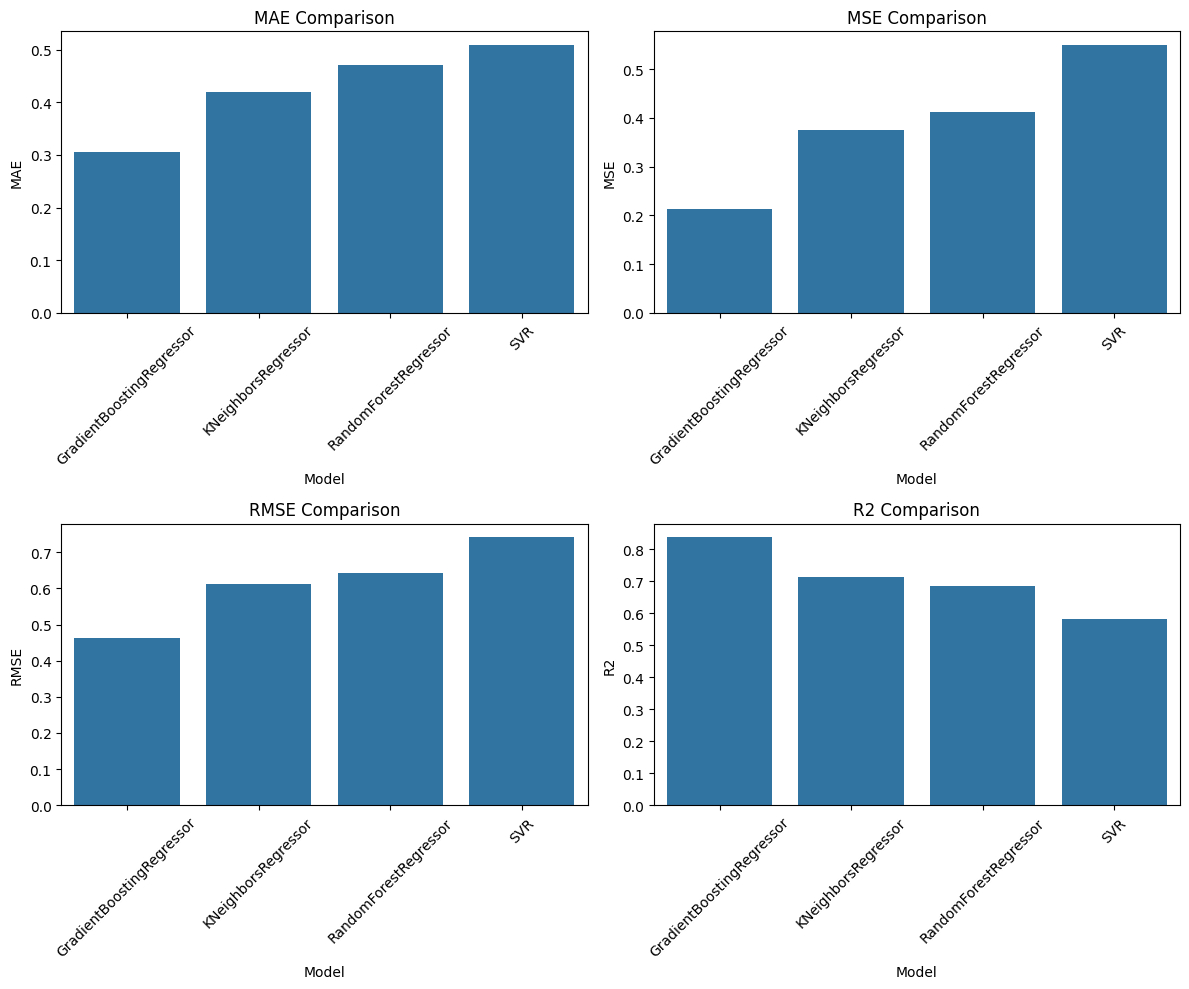

In [34]:
# Plotting the comparison results
metrics = ['MAE', 'MSE', 'RMSE', 'R2']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(x='model_name', y=metric, data=df_results, ax=axes[i])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()